In [40]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from bs4 import BeautifulSoup 
import numpy as np
import matplotlib.pyplot as plt

# P3 Limpieza csv

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vickyotarola/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [84]:

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stop_words.update(['said', 'also', 'one', 'used', 'use', 'would', 'could', 'systems', 'like'])

df = pd.read_csv('../data/corpus_v1.csv')

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-z\s]', '', texto)
    words = texto.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df['texto_limpio'] = df['texto'].apply(limpiar_texto)
vocabulario_total = set(" ".join(df['texto_limpio']).split())
print(f"Tamaño del vocabulario final: {len(vocabulario_total)} palabras únicas.")

df.to_csv('../data/corpus_limpio.csv', index=False)

Tamaño del vocabulario final: 7274 palabras únicas.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vickyotarola/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [85]:

df = pd.read_csv('../data/corpus_limpio.csv')
filas_vacias = df['texto_limpio'].isna()
for index, row in df[filas_vacias].iterrows():
    url = row['url']
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        respuesta = requests.get(url, headers=headers, timeout=10)
        if respuesta.status_code == 200:
            soup = BeautifulSoup(respuesta.text, 'html.parser')
            parrafos = soup.find_all('p')
            texto_extraido = " ".join([p.get_text() for p in parrafos])
            if len(texto_extraido) > 50:
                df.at[index, 'texto_limpio'] = texto_extraido
                print(f"Recuperado: {url}")
            else:
                print(f"La página cargó, pero no se encontró texto en: {url}")
        else:
            print(f"Error {respuesta.status_code} al acceder a: {url}")
    except Exception as e:
        print(f"Fallo de conexión con {url}: {e}")

df.to_csv('../data/corpus_recuperado.csv', index=False)

Recuperado: https://investors.palantir.com/news-details/2026/Palantir-Joins-U-S--Army-and-Industry-Partners-for-Right-to-Integrate-Hackathon-Sprint-for-Defense-wide-Interoperability/
Recuperado: https://investors.palantir.com/news-details/2026/GE-Aerospace-and-Palantir-Expand-Partnership-to-Transform-Military-Aircraft-Readiness-with-AI/
La página cargó, pero no se encontró texto en: https://www.palantir.com/q1-2026-letter/en/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsroom/letters/aip-in-action/en/
La página cargó, pero no se encontró texto en: https://www.palantir.com/q4-2025-letter/en/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsroom/press-releases/palantir-and-oracle-announce-strategic-partnership/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsroom/press-releases/palantir-and-panasonic-energy-expand-partnership/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsro

# P4 Creacion Matriz

In [86]:
df = pd.read_csv('../data/corpus_recuperado.csv')
df_valido = df.dropna(subset=['texto_limpio']).copy()
vectorizador = TfidfVectorizer()
X = vectorizador.fit_transform(df_valido['texto_limpio'])
A_sparse = X.T
A = A_sparse.toarray()
m, n = A.shape
vocabulario = vectorizador.get_feature_names_out()
print(f"Dimensiones de la matriz A: {m} (terminos) x {n} (documentos)")

Dimensiones de la matriz A: 7274 (terminos) x 49 (documentos)


# P5 Calculo de la SVD


In [87]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(S)
print(f"Dimensiones de U: {U.shape}, Sigma: {Sigma.shape}, Vt: {Vt.shape}")

Dimensiones de U: (7274, 49), Sigma: (49, 49), Vt: (49, 49)


# P6 Visualizacion

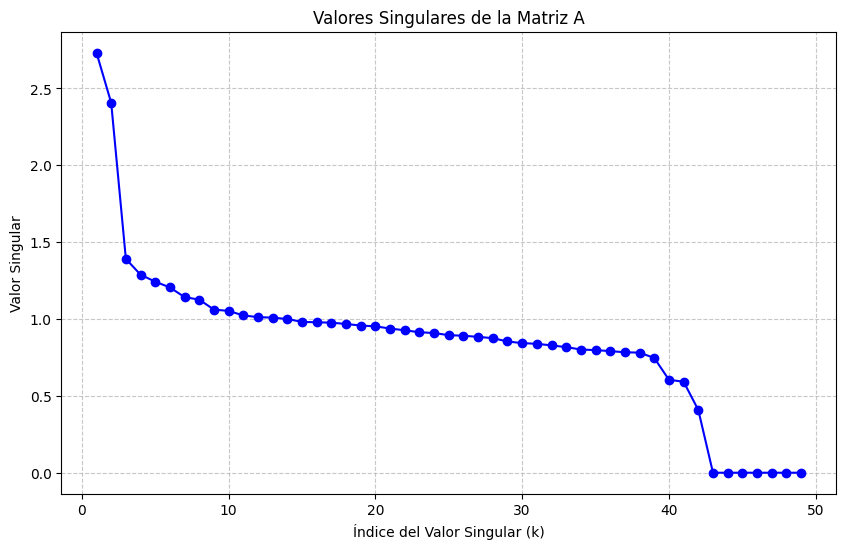

In [88]:
#Creamos el grafico para los valores singulares
plt.figure(figsize=(10,6))
plt.plot(range(1, len(S) + 1), S, marker='o', linestyle='-', color='b') 
plt.title('Valores Singulares de la Matriz A')
plt.xlabel('Índice del Valor Singular (k)')
plt.ylabel('Valor Singular')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("../figures/valores_singulares.png", bbox_inches='tight')
plt.show()



Para elegir el valor de k, vamos a utilizar el método del codo, el cual es una forma sencilla e intuitiva de encontrar el número óptimo de valores singulares para SVD. 

Vamos a observar la visualizacion de los valores singulares en orden descendente y buscar un punto en el que la curva se doble bruscamente, como un codo. Este punto nos indica que los valores singulares restantes tienen poca contribución a los datos y se pueden descartar sin perder mucha información. 

Observando el gráfico vemos que hay una caída inmensa en aproximadamente k=3,el cual consideramos como el codo principal y el mas drástico. Segun lo observado, vemos claramento como los dos priemros valores singulares son muy altos, pero a continuación la curva sufre una caida gigantesca y abrupta que nos señala claramente este "codo" que buscamos, que basicamente es lo que nos dice que casi toda la estrucura principal del corpus (la tensión entre el discurso directo de Palantir y el discurso de la prensa y critico) se explica con solo las componente 1 y 2. A partir de k=3 la indormacion que se agrega es mucho menor

Posteriormente igual hay una caida más suave, pero la consideramos como un codo de estabilización, ya que no negamos que la curva siga bajando suvaemente y formando esta curva hasta aproximadamente k=10 o 11 y es a partir de ahí que la línea se vuelva casi perfectamente horizonal.

Nosotros vamos a elegir k= 3 ya que las dos primeras componentes concentrar una cantidad masiva de la estructura del problema, evidenciable a través de su pronunciamiento abrupto en este k, donde el valor singular car drasticmaente. A partir de este punto consideramos que estariamos eliminadno el mayor ruido posible y por consiguiente lo elegimos para nuestra representación reducida, porque creemos que puede capturar la inmmensa mayoria de la varianza tematica de la diferencia entre los discuros de forma más directa.

Igualmente tenemos en cuenta que si bien el método del codo es fácil de implementar y visualizar, puede ser subjetivo y sensible al ruido.

# P7 Representacion de documentos y terminos en baja dimension


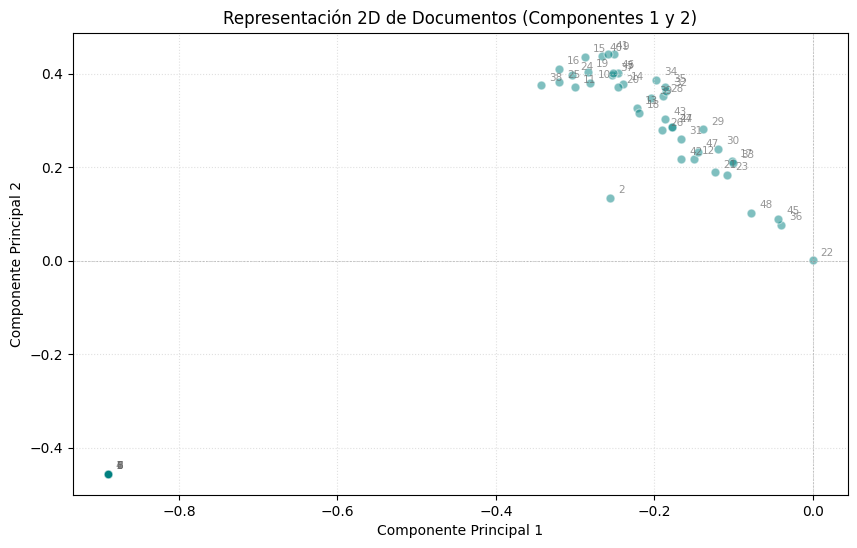

In [89]:
k = 2
# Extraccion de componentes
Uk = U[:, :k]
Sk = np.diag(S[:k])
Vtk = Vt[:k, :]

# Calculamos las coordenadas
# Documentos: D_k = S_k * V^T_k 
Dk = Sk @ Vtk  

# Términos: T_k = U_k * S_k
Tk = Uk @ Sk  

# Elegimos el par de componentes a graficar (0 y 1 son la 1ra y 2da componente)
comp_x = 0 
comp_y = 1 

plt.figure(figsize=(10, 6))

plt.scatter(Dk[comp_x, :], Dk[comp_y, :], alpha=0.5, color='teal', edgecolors='white', linewidth=0.8, s=40)
for i in range(Dk.shape[1]):
    plt.annotate(str(i), 
                 (Dk[comp_x, i] + 0.01, Dk[comp_y, i] + 0.01), 
                 fontsize=7.5,      
                 alpha=0.7,       
                 color='dimgrey')

plt.title(f'Representación 2D de Documentos (Componentes {comp_x+1} y {comp_y+1})')
plt.xlabel(f'Componente Principal {comp_x+1}')
plt.ylabel(f'Componente Principal {comp_y+1}')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

# Una grilla más suave
plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)

plt.savefig("../figures/documentos_2d.png", bbox_inches='tight', dpi=300) # dpi=300 mejora la resolución
plt.show()

Vamos a hacer acercamientos para entender mejor, mostrando dos graficos separados enfocados en ambos extremos

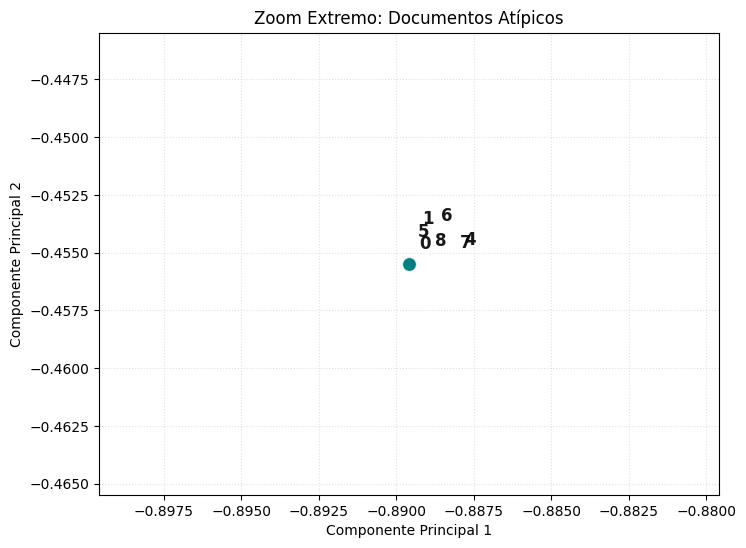

--- IDENTIFICANDO LOS DOCUMENTOS ATÍPICOS ---
Documento #0
Categoría: Corporativo
URL: https://investors.palantir.com/news-details/2026/Palantir-Joins-U-S--Army-and-Industry-Partners-for-Right-to-Integrate-Hackathon-Sprint-for-Defense-wide-Interoperability/
--------------------------------------------------
Documento #1
Categoría: Corporativo
URL: https://investors.palantir.com/news-details/2026/GE-Aerospace-and-Palantir-Expand-Partnership-to-Transform-Military-Aircraft-Readiness-with-AI/
--------------------------------------------------
Documento #12
Categoría: Corporativo
URL: https://investors.palantir.com/news-details/2024/Anthropic-and-Palantir-Partner-to-Bring-Claude-AI-Models-to-AWS-for-U.S.-Government-Intelligence-and-Defense-Operations/
--------------------------------------------------
Documento #13
Categoría: Corporativo
URL: https://investors.palantir.com/news-details/2024/Shield-AI-and-Palantir-Technologies-Deepen-Strategic-Partnership-and-Announce-Deployment-of-Warp-Spee

In [94]:
# Zoom para entender donde estan los outliers
min_x = np.min(Dk[comp_x, :])
min_y = np.min(Dk[comp_y, :])

plt.figure(figsize=(8, 6))
plt.scatter(Dk[comp_x, :], Dk[comp_y, :], alpha=0.7, color='teal', edgecolors='white', linewidth=0.8, s=100)

for i in range(Dk.shape[1]):
    # Solo agregamos etiqueta si el punto está pegado a ese mínimo absoluto
    if Dk[comp_x, i] < min_x + 0.05 and Dk[comp_y, i] < min_y + 0.05:
        # Añadimos un poco de 'ruido' visual al texto para que si están superpuestos se lean mejor
        desplazamiento_x = np.random.uniform(0.0001, 0.002)
        desplazamiento_y = np.random.uniform(0.0001, 0.002)
        
        plt.annotate(str(i), 
                     (Dk[comp_x, i] + desplazamiento_x, Dk[comp_y, i] + desplazamiento_y), 
                     fontsize=12, alpha=0.9, color='black', fontweight='bold')

plt.title(f'Zoom Extremo: Documentos Atípicos')
plt.xlabel(f'Componente Principal {comp_x+1}')
plt.ylabel(f'Componente Principal {comp_y+1}')

# Hacemos un zoom milimétrico alrededor del punto mínimo
plt.xlim(min_x - 0.01, min_x + 0.01)
plt.ylim(min_y - 0.01, min_y + 0.01)

plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)
plt.savefig("../figures/documentos_zoom_outliers.png", bbox_inches='tight', dpi=300)
plt.show()


print("--- IDENTIFICANDO LOS DOCUMENTOS ATÍPICOS ---")
# Filtramos los documentos que cayeron en esa zona extrema
outliers_df = df_valido[(Dk[comp_x, :] < min_x + 0.05) & (Dk[comp_y, :] < min_y + 0.05)]

# Mostramos el índice original, la categoría y la URL (o los primeros 100 caracteres del texto)
for index, row in outliers_df.iterrows():
    print(f"Documento #{index}")
    if 'pilar' in df_valido.columns:
        print(f"Categoría: {row['pilar']}")
    if 'url' in df_valido.columns:
        print(f"URL: {row['url']}")
    print("-" * 50)

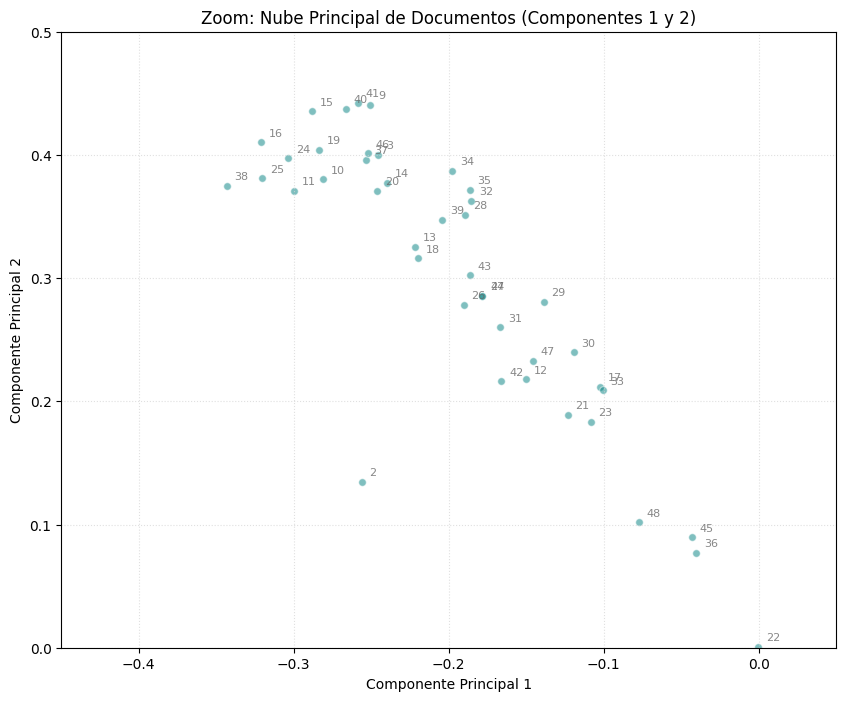

In [91]:
# ZOOM 2: Arriba Derecha
plt.figure(figsize=(10, 8)) # Un poco más grande para que quepan todos los números
# Hacemos los puntos un poco más pequeños y transparentes porque hay muchos juntos
plt.scatter(Dk[comp_x, :], Dk[comp_y, :], alpha=0.5, color='teal', edgecolors='white', linewidth=0.8, s=30)

for i in range(Dk.shape[1]):
    if Dk[comp_x, i] > -0.5 and Dk[comp_y, i] > -0.1:
        plt.annotate(str(i), 
                     (Dk[comp_x, i] + 0.005, Dk[comp_y, i] + 0.005), 
                     fontsize=8, alpha=0.8, color='dimgrey')

plt.title(f'Zoom: Nube Principal de Documentos (Componentes {comp_x+1} y {comp_y+1})')
plt.xlabel(f'Componente Principal {comp_x+1}')
plt.ylabel(f'Componente Principal {comp_y+1}')

# Recortamos los ejes para enfocar la nube
plt.xlim(-0.45, 0.05)
plt.ylim(0.0, 0.5)

plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)
plt.savefig("../figures/documentos_zoom_nube.png", bbox_inches='tight', dpi=300)
plt.show()


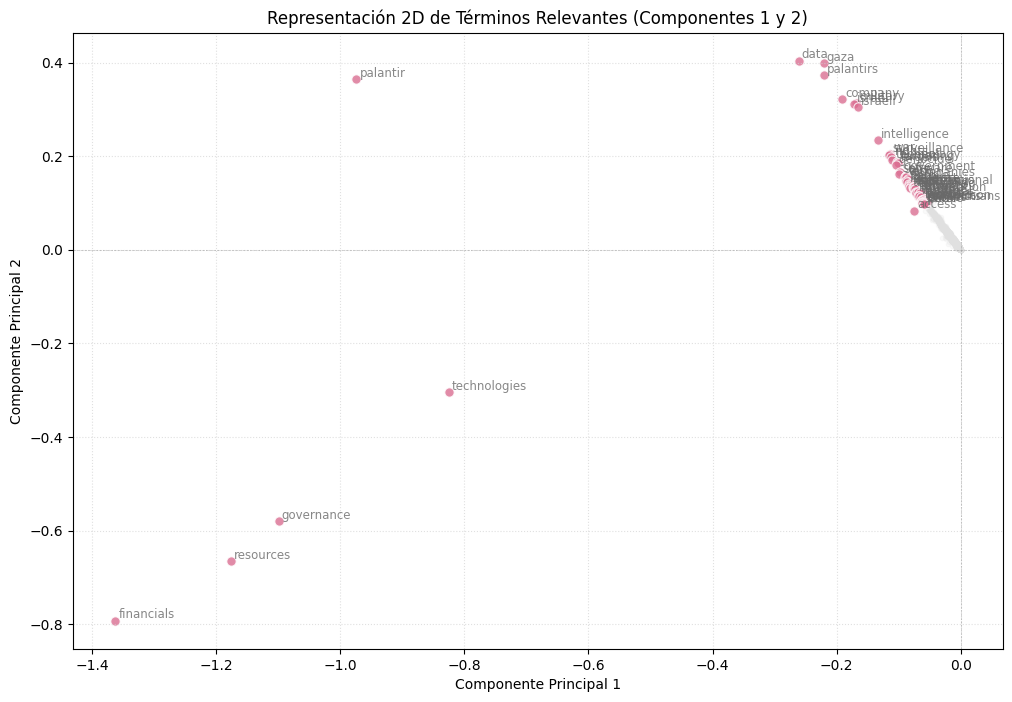

In [92]:
# Visualización de Términos Relevantes 
# calculamos la magnitud de cada palabra en el espacio de 2 dimensiónes
normas_k = np.linalg.norm(Tk, axis=1)
indices_top_terminos = np.argsort(normas_k)[::-1][:60]

plt.figure(figsize=(12, 8))
plt.scatter(Tk[:, comp_x], Tk[:, comp_y], alpha=0.15, color='#e0e0e0', s=10)

# Destacamos los términos más importantes
plt.scatter(Tk[indices_top_terminos, comp_x], Tk[indices_top_terminos, comp_y], 
            color='palevioletred', edgecolors='white', linewidth=0.8, s=45, alpha=0.8)

# Añadimos las etiquetas de texto solo a esos términos top
for i in indices_top_terminos:
    # Redujimos un poco el desplazamiento para que el texto quede más pegadito al punto
    plt.annotate(vocabulario[i], 
                 (Tk[i, comp_x] + 0.005, Tk[i, comp_y] + 0.005),
                 fontsize=8.5,    # Letra un poco más pequeña
                 alpha=0.8,
                 color='dimgrey')

plt.title(f'Representación 2D de Términos Relevantes (Componentes {comp_x+1} y {comp_y+1})')
plt.xlabel(f'Componente Principal {comp_x+1}')
plt.ylabel(f'Componente Principal {comp_y+1}')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)
plt.savefig("../figures/terminos_2d.png", bbox_inches='tight', dpi=300)
plt.show()

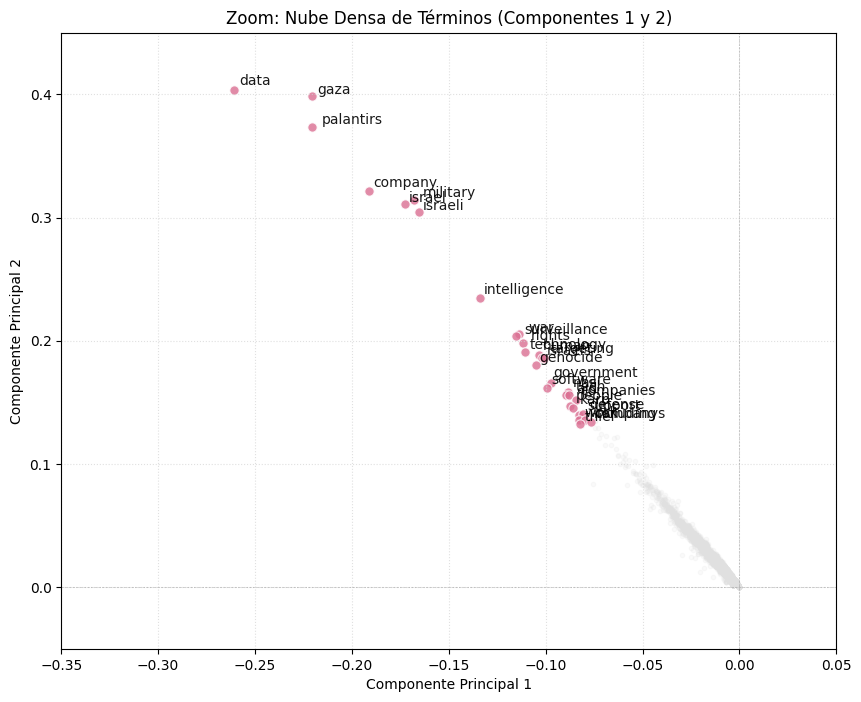

--- TOP 30 PALABRAS EN LA NUBE PRINCIPAL ---
Palabra: 'data' | Coordenadas: (-0.261, 0.404)
Palabra: 'gaza' | Coordenadas: (-0.221, 0.399)
Palabra: 'palantirs' | Coordenadas: (-0.220, 0.373)
Palabra: 'company' | Coordenadas: (-0.191, 0.322)
Palabra: 'military' | Coordenadas: (-0.168, 0.314)
Palabra: 'israel' | Coordenadas: (-0.173, 0.311)
Palabra: 'israeli' | Coordenadas: (-0.166, 0.304)
Palabra: 'intelligence' | Coordenadas: (-0.134, 0.235)
Palabra: 'war' | Coordenadas: (-0.113, 0.206)
Palabra: 'surveillance' | Coordenadas: (-0.115, 0.203)
Palabra: 'rights' | Coordenadas: (-0.112, 0.198)
Palabra: 'technology' | Coordenadas: (-0.111, 0.191)
Palabra: 'human' | Coordenadas: (-0.103, 0.188)
Palabra: 'targeting' | Coordenadas: (-0.102, 0.186)
Palabra: 'israels' | Coordenadas: (-0.101, 0.186)
Palabra: 'genocide' | Coordenadas: (-0.105, 0.181)
Palabra: 'government' | Coordenadas: (-0.097, 0.166)
Palabra: 'software' | Coordenadas: (-0.099, 0.161)
Palabra: 'nhs' | Coordenadas: (-0.088, 0.158)


In [93]:
#hacemos un zoom en las palabras condensadas
plt.figure(figsize=(10, 8))

# Dibujamos el fondo gris tenue con todas las palabras
plt.scatter(Tk[:, comp_x], Tk[:, comp_y], alpha=0.15, color='#e0e0e0', s=10)

# Buscamos las palabras que cayeron específicamente en ese cuadrante (X > -0.35, Y > 0.0)
indices_nube_palabras = np.where((Tk[:, comp_x] > -0.35) & (Tk[:, comp_y] > 0.0))[0]

# Calculamos sus magnitudes y nos quedamos con las 30 más fuertes de esa zona para no saturar
magnitudes_nube = np.linalg.norm(Tk[indices_nube_palabras], axis=1)
top_indices_nube = indices_nube_palabras[np.argsort(magnitudes_nube)[::-1][:30]]
plt.scatter(Tk[top_indices_nube, comp_x], Tk[top_indices_nube, comp_y], 
            color='palevioletred', edgecolors='white', linewidth=0.8, s=45, alpha=0.8)

# Etiquetamos solo esas palabras top dentro del zoom
for i in top_indices_nube:
    # Añadimos un poco de 'ruido' para separar palabras muy pegadas
    desplazamiento_x = np.random.uniform(0.001, 0.005)
    desplazamiento_y = np.random.uniform(0.001, 0.005)
    
    plt.annotate(vocabulario[i], 
                 (Tk[i, comp_x] + desplazamiento_x, Tk[i, comp_y] + desplazamiento_y),
                 fontsize=10, alpha=0.9, color='black')

plt.title(f'Zoom: Nube Densa de Términos (Componentes {comp_x+1} y {comp_y+1})')
plt.xlabel(f'Componente Principal {comp_x+1}')
plt.ylabel(f'Componente Principal {comp_y+1}')

# Recortamos los ejes para enfocar la nube superior derecha
plt.xlim(-0.35, 0.05)
plt.ylim(-0.05, 0.45)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)
plt.savefig("../figures/terminos_zoom_nube.png", bbox_inches='tight', dpi=300)
plt.show()

print("--- TOP 30 PALABRAS EN LA NUBE PRINCIPAL ---")
for i in top_indices_nube:
    print(f"Palabra: '{vocabulario[i]}' | Coordenadas: ({Tk[i, comp_x]:.3f}, {Tk[i, comp_y]:.3f})")


### El eje Y
El eje y, es decir el componente principal 2 está dividiendo la información de nuestro corpus evidentemente en dos mundos con vocabularios totalmente distintos

- zona superior (Y positivo): Aqui se nota que hay un cluster muy denso, y a medida que aumentamos la cantidad de palabras se densifica más, las palabras como "military", "gaza", "surveullance", "genocide" se encuentran en esta parte de nuesto gradico. Este grupo creemos que representa claramente el rol que tiene la empresa Palantir en conflictos geopoliticos y contratos de defensa y seguridad. Es el escenario donde podemos cuestionar los sistemas sociotecnicos de esta empresa, para entender mejor las fuertes implicancias que tiene a nivel ético y social, ya nuestro modelo logro aislar la controversia algoritmica y militar en este cuadrante

- zona inferior (Y negativo): es el extremo opuesto al anterior, vemos terminos como "financials", "governance" y "resources". Este grupo nos representa el lado netamente corporativo, administrativo y burocratico.

### El eje X

- Analizando específicamente el componente prinicpal 1 nos da una lectura que complementa lo que describimos antes con el eje Y. Matematicamente, la priemra componente de un SVD es la que captura la dirección de "maxima varianza" o el tema que consideramos dominante. Como notamos casi todas las palabras estan en el lado negativo del eje X, en este caso, lo que impora es la magnitud, es decir que tan lejos estan del cero hacia la izquierda.
Si nos fijamos en las palabras que el modelo empujó más hacia el extremo izquierdo (las que tienen mayor magnitud en la Componente 1), encontramos

- financials (cerca de -1.38)

- resources (cerca de -1.18)

- governance (cerca de -1.10)

- palantir (cerca de -0.98)

- technologies (cerca de -0.82)

Estas palabras definen la identidad burocrática, financiera y corporativa de la empresa. El hecho de que tengan el mayor peso en la Componente 1 significa directamente que el vocabulario de negocios es la mayor fuente de variación en el corpus que escogimos.

Por el contrario, al observar la nube densa donde están los términos del conflicto y la crítica (gaza, military, surveillance, human, rights). Todas estas palabras están "aplastadas" muy cerca del 0.0 en el eje X (entre -0.2 y 0.0).

Esto lo entendemos como que para la Componente 1, estas palabras casi no tienen peso. El algoritmo detectó que cuando se habla de "finanzas" y "gobernanza", se usa un lenguaje tan denso y particular que domina el modelo, mientras que el vocabulario sobre el terreno (lo militar, lo ético) opera en una frecuencia totalmente distinta.

Podemos entender los ejemplos siguientes como demostraciónes concretas de relaciones:

- La cercanía extrema entre "surveillance", "intelligence", "military" y los nombres de zonas de conflicto, como "gaza" confirmarian que, dentro de este corpus que hemos construido, la vigilancia tecnologíca y la recolección de datos se discuten de la mano con la inteligencia militar y no como una herramienta comercial sin implicaciones.
- Igualmente es revelador notar como la palabra "technologies" se ubica mas en el centro, funcionando como un puente entre las zonas, mientras que palabras como "fiancials" y "genocide" están en los extremos opuestos del gráfico. Esto nos indica que matematicamente podemos demostrar que los documentos que reportan el exito corporativo y financiero están a su vez aislando por completo el vocabulario relacionado con el impacto etico y humano de los conflicos armados en los que se ven involucrados

# P8

## Ejemplo 1:

Lo que observamos en el grafico de terminos, el cual es la representación bidimensional de estos, es evidente que el espacio latenten polariza bastante el vocabulario del corpus en dos extremos. Por un lado la Segunda Componente Principal (el Eje Y) separa  las temáticas. En el polo superior se consolida un clúster muy denso asociado al conflicto y los derechos humanos, con palabras clave como military, surveillance, intelligence, israel, gaza y genocide. En contraste, el extremo inferior agrupa de forma aislada el vocabulario administrativo e institucional, tales como financials, governance y resources. Adicionalmente, la Primera Componente (el Eje X) empuja esta jerga corporativa hacia el extremo negativo, demostrando que el lenguaje financiero es la mayor fuente de variación en los documentos del corupus

Esta separación es matemáticamente coherente y revela cómo la SVD logra capturar las implicancias éticas de la empresa Palantir. El algoritmo evidencia empíricamente que el discurso corporativo y financiero se aísla por completo de la aplicación en terreno de sus sistemas. Las plataformas de recolección de datos pierden su supuesta "neutralidad algorítmica" al revelar dos vocabularios desconectados: uno enfocado en la gobernanza y rentabilidad que omite el conflicto, y otro que refleja el contexto real de vigilancia militar. Es esperable y coherente que los reportes de la empresa omitan el lenguaje del clúster superior, generando esta fractura medible entre el discurso oficial y el impacto sociotécnico de sus tecnologías.

## Ejemplo 2:
Al proyectar los documentos en el espacio latente bidimensional, se observa que la gran mayoría conforma una nube semántica densa en la mitad superior del gráfico (ej. documentos 29, 30, 36). Sin embargo, se identifican claros outliers o valores atípicos posicionados en el extremo inferior izquierdo, específicamente los documentos como el 0 y 1. Al inspeccionar directamente las URLs correspondientes a estos puntos aislados, corroboramos empíricamente que pertenecen al pilar "Corporativo" del corpus, tratándose de documentación oficial proveniente del portal mismo de Palantir.

Al cruzar esta distribución espacial con la visualización de términos anterior, es coherente deducir que la nube principal agrupa los comunicados de prensa y los reportes de ONGs, mientras que la documentación entregada por la propia empresa rompe radicalmente con ese patrón discursivo. Resulta sorprendente observar con qué precisión la SVD logra aislar estos textos de manera puramente no supervisada; es decir, sin saber su procedencia y basándose exclusivamente en la coocurrencia de palabras.

Este hallazgo demuestra que la narrativa estructurada por quienes desarrollan la tecnología es incapaz de asimilar o reconocer los impactos de la misma en el mundo real. El discurso oficial de la empresa queda confinado a un ecosistema léxico propio, enfocado estrictamente en tecnicismos y rendimiento financiero, totalmente desconectado del debate público y las noticias sobre el uso de sus sistemas.

## Ejemplo 3:
En la visualización de terminos,observamos que la palabra technologies se sitúa en una posición intermedia respecto a la Segunda Componente Principal (Eje Y), pero presenta una fuerte carga negativa en la Primera Componente (Eje X), ubicándose fuertemente asociada al término palantir. Este comportamiento espacial resulta altamente coherente, ya que la "tecnología" opera como el concepto central y la infraestructura subyacente para ambos polos semánticos.

Más que un elemento diferenciador, este término actúa como un puente discursivo: representa el producto centralizado que sustenta el éxito corporativo (asociado al clúster de financials) y, simultáneamente, es la herramienta de vigilancia (surveillance) desplegada en zonas de conflicto como Gaza. Al tratarse de un término estructural compartido por la gran mayoría de los documentos del corpus, independientemente de su postura crítica o corporativa, el algoritmo SVD no lo proyecta hacia los extremos temáticos de variación, sino que es esperable y entendible que lo ancle firmemente en el núcleo del espacio latente.


Una limitación observada en el análisis radica en la fase de preprocesamiento. Si bien se utilizó la librería NLTK para la eliminación de 'stopwords' estándar, la representación espacial retuvo términos genéricos de alta frecuencia propios del género periodístico (tales como 'said', 'also', 'used', 'one'). Esto demuestra que para análisis semánticos más limpios en SVD, no basta con diccionarios genéricos, sino que es necesario iterar y construir un diccionario de stopwords personalizado al dominio del corpus.